# Inspect One Transformer Batch - v15

This notebook loads one provider-built 1m-bar batch, checks tensor shapes and finite values, loads a model checkpoint if provided, runs one inference, and computes one Smooth L1 loss.

In [1]:
from pathlib import Path

MODEL_VERSION = "v15"
MODEL_ROOT = Path(r"D:\\TradingData\\quant-research-workbench\\market_data\\models\\inhouse_transformer") / MODEL_VERSION

# Edit these values for the batch/checkpoint you want to inspect.
WORKSPACE = Path(r"D:\\TradingCodes\\quant-research-workbench")
SESSION_DATE = "2024-01-22"
TICKERS = ("USO",)  # Use a small tuple first. Example: ("USO", "CADL")
BATCH_SIZE = 16
CONTEXT_LENGTH = 64
HORIZON = 1
TARGET_COLUMNS = ("close",)
TARGET_MODE = "ordinal_exceedance_bps"
SESSION_SCOPE = "all"
DEVICE = "cuda"  # Use "cpu" if CUDA is unavailable.
USE_AMP = False  # Keep False while checking exact tensors/losses.
LOAD_CHECKPOINT_CONFIG = True  # Use checkpoint model/data shape when CHECKPOINT_PATH is set.

# Paste a checkpoint path, or leave empty to auto-load the latest v15 last.pt/best.pt under MODEL_ROOT.
CHECKPOINT_PATH = ""
# Example:
# CHECKPOINT_PATH = str(MODEL_ROOT / "feature_temporal_v15_ordinal_exceedance_bps_ctx64_h1_..." / "last.pt")

In [2]:
import sys
import math
from dataclasses import fields
import numpy as np
import polars as pl
import torch

if str(WORKSPACE) not in sys.path:
    sys.path.insert(0, str(WORKSPACE))

from research.inhouse_transformer.v15.config import DataConfig, ModelConfig, ExperimentConfig
from research.inhouse_transformer.v15.data import RollingBarWindowDataset, available_sessions, target_values_to_bps
from research.inhouse_transformer.v15.model import FeatureTemporalTransformer, forecast_loss

np.set_printoptions(precision=5, suppress=True)
torch.set_printoptions(precision=5, sci_mode=False)

def dataclass_from_dict(cls, payload, tuple_fields=()):
    allowed = {field.name for field in fields(cls)}
    values = {key: value for key, value in payload.items() if key in allowed}
    if cls is DataConfig and "processed_root" in values:
        values["processed_root"] = Path(values["processed_root"])
    for name in tuple_fields:
        if name in values:
            values[name] = tuple(values[name])
    return cls(**values)

def latest_checkpoint(model_root):
    candidates = list(model_root.glob("*/last.pt")) + list(model_root.glob("*/best.pt"))
    return max(candidates, key=lambda path: path.stat().st_mtime) if candidates else None

checkpoint = None
checkpoint_path = Path(CHECKPOINT_PATH) if CHECKPOINT_PATH else latest_checkpoint(MODEL_ROOT)
if checkpoint_path:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    checkpoint_config = checkpoint.get("config", {}) if isinstance(checkpoint, dict) else {}
else:
    checkpoint_config = {}
checkpoint_version = checkpoint_config.get("experiment_version") if checkpoint_config else None
if checkpoint_version and checkpoint_version != MODEL_VERSION:
    raise ValueError(f"Checkpoint version {checkpoint_version!r} does not match notebook version {MODEL_VERSION!r}.")

if checkpoint_config and LOAD_CHECKPOINT_CONFIG:
    data_config = dataclass_from_dict(
        DataConfig,
        checkpoint_config.get("data", {}),
        tuple_fields=("target_columns", "input_feature_columns", "time_feature_columns", "tickers"),
    )
    model_config = dataclass_from_dict(ModelConfig, checkpoint_config.get("model", {}))
    print("using data/model shape from checkpoint config")
else:
    data_config = DataConfig(
        context_length=CONTEXT_LENGTH,
        horizon=HORIZON,
        target_mode=TARGET_MODE,
        target_columns=TARGET_COLUMNS,
        input_normalization="window_zscore_only",
    )
    model_config = ModelConfig()

# These are inspection controls, so they intentionally override checkpoint split/ticker settings.
data_config.train_start_date = SESSION_DATE
data_config.train_end_date = SESSION_DATE
data_config.validation_start_date = SESSION_DATE
data_config.validation_end_date = SESSION_DATE
data_config.test_start_date = SESSION_DATE
data_config.test_end_date = SESSION_DATE
data_config.session_scope = SESSION_SCOPE
data_config.tickers = TICKERS
data_config.max_tickers = len(TICKERS)
experiment_config = ExperimentConfig(data=data_config, model=model_config)

device = torch.device(DEVICE if DEVICE == "cpu" or torch.cuda.is_available() else "cpu")
print(f"device={device}")
print(f"input_features={len(data_config.input_feature_columns)} {data_config.input_feature_columns}")
print(f"context={data_config.context_length} horizon={data_config.horizon} targets={data_config.target_columns}")
print(f"target_mode={data_config.target_mode} input_normalization={data_config.input_normalization}")
print(f"time_features={len(data_config.time_feature_columns)} {data_config.time_feature_columns}")
print(f"targets={data_config.target_columns} horizon={data_config.horizon} target_mode={data_config.target_mode}")
print(f"input_normalization={data_config.input_normalization}")

using data/model shape from checkpoint config
device=cuda
input_features=12 ('open', 'high', 'low', 'close', 'volume', 'transactions', 'spread_bps', 'quote_bid_size', 'quote_ask_size', 'quoted_share_depth', 'quote_imbalance', 'quote_valid_ratio')
context=64 horizon=1 targets=('close',)
target_mode=ordinal_exceedance_bps input_normalization=window_zscore_only
time_features=19 ('minute_sin', 'minute_cos', 'regular_position_sin', 'regular_position_cos', 'is_premarket', 'is_regular', 'is_afterhours', 'is_new_session', 'gap_minutes_clipped', 'year_scaled', 'month_scaled', 'day_scaled', 'hour_scaled', 'minute_scaled', 'second_scaled', 'microsecond_scaled', 'minute_of_day_scaled', 'day_of_year_scaled', 'day_of_week_scaled')
targets=('close',) horizon=1 target_mode=ordinal_exceedance_bps
input_normalization=window_zscore_only


In [3]:
sessions = available_sessions(data_config.processed_root, SESSION_DATE, SESSION_DATE)
dataset = RollingBarWindowDataset(
    config=data_config,
    sessions=sessions,
    tickers=TICKERS,
    batch_size=BATCH_SIZE,
    seed=17,
    mode="inspect",
    max_windows=BATCH_SIZE,
    shuffle=False,
)

batch = next(iter(dataset))
print("batch keys:", sorted(batch.keys()))
for key, value in batch.items():
    if torch.is_tensor(value):
        finite = bool(torch.isfinite(value).all())
        min_value = float(value.min()) if value.numel() else math.nan
        max_value = float(value.max()) if value.numel() else math.nan
        print(f"{key:20s} shape={tuple(value.shape)} dtype={value.dtype} finite={finite} min={min_value:.6g} max={max_value:.6g}")
    else:
        print(f"{key:20s} type={type(value).__name__} len={len(value) if hasattr(value, '__len__') else 'n/a'} sample={value[:5] if isinstance(value, list) else value}")

************************************************************************************************
*** INSPECT SESSION START 2024-01-22 | epoch 1/1 | session 1/1
batch keys: ['current_close', 'last_close_return_bps', 'target_bps', 'target_center', 'target_scale', 'target_timestamp_ns', 'targets', 'ticker', 'time_features', 'values']
values               shape=(16, 64, 12) dtype=torch.float32 finite=True min=-3.7925 max=6.58154
time_features        shape=(16, 64, 19) dtype=torch.float32 finite=True min=-0.848048 max=1
targets              shape=(16, 1, 1, 40) dtype=torch.float32 finite=True min=0 max=1
target_bps           shape=(16, 1, 1) dtype=torch.float32 finite=True min=-15.8901 max=24.5722
current_close        shape=(16,) dtype=torch.float32 finite=True min=69.01 max=69.34
target_center        shape=(16,) dtype=torch.float32 finite=True min=0 max=0
target_scale         shape=(16,) dtype=torch.float32 finite=True min=1 max=1
last_close_return_bps shape=(16,) dtype=torch.float32 finit

In [4]:
batch["values"]

tensor([[[-3.21142, -2.92150, -2.82820,  ...,  0.09627, -0.99562,  0.00000],
         [-3.47630, -3.42890, -3.07001,  ..., -0.45937, -0.86690,  0.00000],
         [-1.10082, -1.15265, -0.90147,  ...,  0.42295,  0.18437,  0.00000],
         ...,
         [ 0.90800,  1.23065,  0.93233,  ..., -1.87103,  0.13717,  0.00000],
         [ 1.47329,  1.60516,  1.44838,  ..., -0.16011, -1.75808,  0.00000],
         [ 1.61617,  1.50534,  1.56615,  ..., -1.54474,  1.12837,  0.00000]],

        [[-3.79250, -3.68162, -3.29262,  ..., -0.46254, -0.89082,  0.00000],
         [-1.25681, -1.28744, -1.01773,  ...,  0.41915,  0.16878,  0.00000],
         [-1.39715, -1.41995, -1.14364,  ..., -0.30678, -0.66376,  0.00000],
         ...,
         [ 1.49090,  1.61325,  1.44737,  ..., -0.16349, -1.78906,  0.00000],
         [ 1.64341,  1.50826,  1.57090,  ..., -1.54713,  1.12025,  0.00000],
         [ 1.72263,  1.65695,  1.57215,  ...,  0.31680,  0.07083,  0.00000]],

        [[-1.48836, -1.51349, -1.17880,  ...

In [5]:
# Inspect the first sample's latest context bar after input normalization.
feature_names = list(data_config.input_feature_columns)
time_feature_names = list(data_config.time_feature_columns)
last_values = batch["values"][0, -1].numpy()
last_time_features = batch["time_features"][0, -1].numpy()

print("first sample ticker:", batch.get("ticker", [None])[0])
print("current_close:", float(batch["current_close"][0]))
print("target_center:", float(batch["target_center"][0]), "target_scale:", float(batch["target_scale"][0]))

pl.DataFrame({"feature": feature_names, "normalized_value_at_context_end": last_values}).head(20)

first sample ticker: USO
current_close: 69.04000091552734
target_center: 0.0 target_scale: 1.0


feature,normalized_value_at_context_end
str,f32
"""open""",1.616168
"""high""",1.505343
"""low""",1.566153
"""close""",1.444875
"""volume""",0.842536
…,…
"""quote_bid_size""",-0.517476
"""quote_ask_size""",-1.87586
"""quoted_share_depth""",-1.544743


In [6]:
model = FeatureTemporalTransformer(
    feature_count=len(data_config.input_feature_columns),
    time_feature_count=len(data_config.time_feature_columns),
    context_length=data_config.context_length,
    horizon=data_config.horizon,
    target_count=len(data_config.target_columns),
    config=model_config,
).to(device)

if checkpoint is not None:
    state_dict = checkpoint.get("model", checkpoint)
    model.load_state_dict(state_dict, strict=True)
    print(f"loaded checkpoint: {checkpoint_path}")
    print("checkpoint step:", checkpoint.get("step"), "best_score:", checkpoint.get("best_score"))
else:
    print("CHECKPOINT_PATH is empty; using fresh randomly initialized model.")

param_count = sum(parameter.numel() for parameter in model.parameters())
print(f"model parameters={param_count:,}")

D:\TradingCodes\quant-research-workbench\research\inhouse_transformer\v15\model.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.feature_encoder = nn.TransformerEncoder(feature_layer, num_layers=config.feature_attention_layers)
D:\TradingCodes\quant-research-workbench\research\inhouse_transformer\v15\model.py:60: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=config.temporal_layers)


loaded checkpoint: D:\TradingData\quant-research-workbench\market_data\models\inhouse_transformer\v15\feature_temporal_v15_ordinal_exceedance_bps_ctx64_h1_2024-01-22_2026-04-09_20260526_073745\last.pt
checkpoint step: 2275 best_score: 6.913727307496324
model parameters=5,924,137


### v15 Model Summary

Forward input shapes: [(1, 64, 12), (1, 64, 19)]
torchinfo is not installed; using the local hook-based summary fallback.
Output shape: (1, 1, 1, 40)
Total params: 5,924,137
Trainable params: 5,924,137


,layer,type,input_shape,output_shape,params,trainable
0,value_projection,Linear,"[(1, 64, 12, 1)]","(1, 64, 12, 256)",512,512
1,feature_embedding,Embedding,"[(12,)]","(12, 256)",3072,3072
2,position_embedding,Embedding,"[(64,)]","(64, 256)",16384,16384
3,time_projection.0,Linear,"[(1, 64, 19)]","(1, 64, 256)",5120,5120
4,time_projection.1,GELU,"[(1, 64, 256)]","(1, 64, 256)",0,0
5,time_projection.2,Linear,"[(1, 64, 256)]","(1, 64, 256)",65792,65792
6,feature_encoder.layers.0.norm1,LayerNorm,"[(64, 12, 256)]","(64, 12, 256)",512,512
7,feature_encoder.layers.0.dropout1,Dropout,"[(64, 12, 256)]","(64, 12, 256)",0,0
8,feature_encoder.layers.0.norm2,LayerNorm,"[(64, 12, 256)]","(64, 12, 256)",512,512
9,feature_encoder.layers.0.linear1,Linear,"[(64, 12, 256)]","(64, 12, 1024)",263168,263168


Graphviz dot executable: C:\Users\g835l\miniconda3\envs\ml4t\Library\bin\dot.EXE


couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

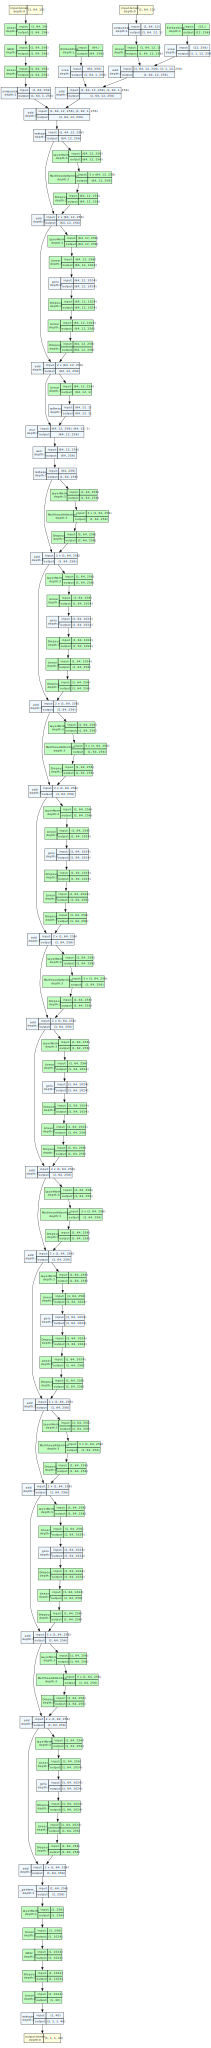

In [7]:
# Keras-style model summary and graph view.
# Optional packages for richer output:
#   pip install torchinfo torchview graphviz
# Graph rendering also needs the Graphviz dot executable on PATH.

import inspect
import os
import shutil
import sys
from pathlib import Path
from IPython.display import Markdown, display

SUMMARY_BATCH_SIZE = 1
SUMMARY_DEPTH = 8
GRAPH_DEPTH = 3


def _active_data_config():
    if "data_config" in globals():
        return data_config
    if "config" in globals() and hasattr(config, "data"):
        return config.data
    raise NameError("Run the config/model setup cells before this summary cell.")


def _model_device(model_obj):
    try:
        return next(model_obj.parameters()).device
    except StopIteration:
        return torch.device("cpu")


def _shape_of(value):
    if torch.is_tensor(value):
        return tuple(value.shape)
    if isinstance(value, (list, tuple)):
        return [_shape_of(item) for item in value]
    if isinstance(value, dict):
        return {key: _shape_of(item) for key, item in value.items()}
    return type(value).__name__


def _slice_input_tensor(value, rows, device):
    if torch.is_tensor(value):
        return value[:rows].to(device)
    return torch.as_tensor(value[:rows]).to(device)


def _branch_time_feature_count(branch):
    projection = getattr(branch, "time_projection", None)
    if projection is not None:
        for module in projection.modules():
            if isinstance(module, torch.nn.Linear):
                return int(module.in_features)
    data_cfg = _active_data_config()
    return len(getattr(data_cfg, "time_feature_columns", ()))


def _synthetic_input_for(name, rows, device):
    data_cfg = _active_data_config()
    dtype = torch.float32

    if name == "values":
        if hasattr(model, "feature_count"):
            return torch.zeros(rows, model.context_length, model.feature_count, dtype=dtype, device=device)
        return torch.zeros(
            rows,
            model.one_min_encoder.context_length,
            model.one_min_encoder.feature_count,
            dtype=dtype,
            device=device,
        )
    if name == "time_features":
        if hasattr(model, "time_projection"):
            time_count = len(getattr(data_cfg, "time_feature_columns", ()))
            return torch.zeros(rows, model.context_length, time_count, dtype=dtype, device=device)
        return torch.zeros(
            rows,
            model.one_min_encoder.context_length,
            _branch_time_feature_count(model.one_min_encoder),
            dtype=dtype,
            device=device,
        )

    branch_by_name = {
        "five_min_values": "five_min_encoder",
        "five_min_time_features": "five_min_encoder",
        "thirty_min_values": "thirty_min_encoder",
        "thirty_min_time_features": "thirty_min_encoder",
        "anchor_values": "anchor_encoder",
        "anchor_time_features": "anchor_encoder",
    }
    if name in branch_by_name:
        branch = getattr(model, branch_by_name[name])
        if name.endswith("time_features"):
            feature_count = _branch_time_feature_count(branch)
        else:
            feature_count = branch.feature_count
        return torch.zeros(rows, branch.context_length, feature_count, dtype=dtype, device=device)

    raise ValueError(f"Do not know how to build summary input for forward argument {name!r}.")


def _summary_inputs():
    device_for_summary = _model_device(model)
    forward_names = [
        name
        for name, parameter in inspect.signature(model.forward).parameters.items()
        if name != "self" and parameter.kind in (parameter.POSITIONAL_OR_KEYWORD, parameter.KEYWORD_ONLY)
    ]
    rows = SUMMARY_BATCH_SIZE
    if "batch" in globals() and all(name in batch for name in forward_names):
        rows = min(SUMMARY_BATCH_SIZE, int(batch[forward_names[0]].shape[0]))
        return tuple(_slice_input_tensor(batch[name], rows, device_for_summary) for name in forward_names)
    return tuple(_synthetic_input_for(name, rows, device_for_summary) for name in forward_names)


def _display_full_dataframe(frame):
    try:
        import pandas as pd

        with pd.option_context(
            "display.max_rows",
            None,
            "display.max_columns",
            None,
            "display.max_colwidth",
            None,
            "display.width",
            0,
            "display.expand_frame_repr",
            False,
        ):
            display(frame)
    except ModuleNotFoundError:
        for row in frame:
            print(row)


def _fallback_summary(model_obj, inputs):
    rows = []
    hooks = []
    module_names = {module: name for name, module in model_obj.named_modules()}

    def register_hook(module):
        if module is model_obj or list(module.children()):
            return

        def hook(mod, mod_inputs, mod_outputs):
            params = sum(parameter.numel() for parameter in mod.parameters(recurse=False))
            trainable = sum(parameter.numel() for parameter in mod.parameters(recurse=False) if parameter.requires_grad)
            rows.append(
                {
                    "layer": module_names.get(mod, ""),
                    "type": mod.__class__.__name__,
                    "input_shape": _shape_of(mod_inputs),
                    "output_shape": _shape_of(mod_outputs),
                    "params": params,
                    "trainable": trainable,
                }
            )

        hooks.append(module.register_forward_hook(hook))

    for module in model_obj.modules():
        register_hook(module)

    was_training = model_obj.training
    model_obj.eval()
    with torch.inference_mode():
        outputs = model_obj(*inputs)
    for hook in hooks:
        hook.remove()
    model_obj.train(was_training)

    print(f"Output shape: {_shape_of(outputs)}")
    total_params = sum(parameter.numel() for parameter in model_obj.parameters())
    trainable_params = sum(parameter.numel() for parameter in model_obj.parameters() if parameter.requires_grad)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    try:
        import pandas as pd

        _display_full_dataframe(pd.DataFrame(rows))
    except ModuleNotFoundError:
        for row in rows:
            print(row)


def _candidate_dot_paths():
    explicit = os.environ.get("GRAPHVIZ_DOT")
    if explicit:
        yield Path(explicit)

    roots = [Path(sys.prefix)]
    conda_prefix = os.environ.get("CONDA_PREFIX")
    if conda_prefix:
        roots.append(Path(conda_prefix))
    for root in roots:
        yield root / "Library" / "bin" / "dot.exe"
        yield root / "bin" / "dot.exe"

    for env_name in ("ProgramFiles", "ProgramFiles(x86)"):
        base = os.environ.get(env_name)
        if not base:
            continue
        base_path = Path(base)
        yield base_path / "Graphviz" / "bin" / "dot.exe"
        for candidate in base_path.glob("Graphviz*\\bin\\dot.exe"):
            yield candidate


def _ensure_graphviz_dot_on_path():
    if shutil.which("dot"):
        return True, shutil.which("dot")

    for candidate in _candidate_dot_paths():
        if candidate and candidate.exists():
            os.environ["PATH"] = str(candidate.parent) + os.pathsep + os.environ.get("PATH", "")
            os.environ["GRAPHVIZ_DOT"] = str(candidate)
            return True, str(candidate)

    return False, None


def _print_graphviz_install_help():
    print("Graphviz dot.exe was not found on PATH, so the torchview graph cannot be rendered.")
    print("The Python graphviz package is only a wrapper; Windows also needs the Graphviz executable.")
    print("Recommended conda fix inside ml4t: conda install -n ml4t -c conda-forge graphviz python-graphviz")
    print(r"Or install Graphviz for Windows and add its bin folder, for example C:\Program Files\Graphviz\bin, to PATH.")


summary_inputs = _summary_inputs()
input_shapes = [_shape_of(tensor) for tensor in summary_inputs]
display(Markdown(f"### {MODEL_VERSION} Model Summary"))
print("Forward input shapes:", input_shapes)

try:
    from torchinfo import summary

    summary_result = summary(
        model,
        input_data=summary_inputs,
        depth=SUMMARY_DEPTH,
        col_names=("input_size", "output_size", "num_params", "trainable"),
        row_settings=("var_names",),
        verbose=0,
        device=str(_model_device(model)),
    )
    print(summary_result)
except ModuleNotFoundError:
    print("torchinfo is not installed; using the local hook-based summary fallback.")
    _fallback_summary(model, summary_inputs)
except Exception as exc:
    print(f"torchinfo summary failed: {exc}")
    print("Using the local hook-based summary fallback.")
    _fallback_summary(model, summary_inputs)

try:
    from torchview import draw_graph

    dot_ready, dot_path = _ensure_graphviz_dot_on_path()
    if not dot_ready:
        _print_graphviz_install_help()
    else:
        print(f"Graphviz dot executable: {dot_path}")
        graph = draw_graph(
            model,
            input_data=summary_inputs,
            graph_name=f"{MODEL_VERSION}_model",
            depth=GRAPH_DEPTH,
            expand_nested=False,
            save_graph=False,
            device=str(_model_device(model)),
        )
        display(graph.visual_graph)
except ModuleNotFoundError:
    print("torchview is not installed, so the graph view is skipped. Install torchview and graphviz for a plot_model-style graph.")
except Exception as exc:
    if "dot" in str(exc).lower() or "executable" in str(exc).lower():
        _print_graphviz_install_help()
    else:
        print(f"torchview graph failed: {exc}")


In [ ]:
def move_tensor_batch(batch, device):
    return {key: value.to(device, non_blocking=True) if torch.is_tensor(value) else value for key, value in batch.items()}

model.eval()
device_batch = move_tensor_batch(batch, device)
with torch.inference_mode():
    with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP and device.type == "cuda"):
        prediction = model(device_batch["values"], device_batch["time_features"])
        loss, loss_parts = forecast_loss(
            prediction,
            device_batch["targets"],
        )

print("prediction shape:", tuple(prediction.shape))
print("loss:", float(loss.detach().cpu()))
print("loss_parts:", loss_parts)
print("prediction finite:", bool(torch.isfinite(prediction).all()))
print("target finite:", bool(torch.isfinite(device_batch["targets"]).all()))

In [ ]:
def prediction_and_target_prices(prediction_tensor, batch_dict, data_config):
    pred_bps_local = target_values_to_bps(
        prediction_tensor.detach().cpu().numpy(),
        batch_dict["current_close"].detach().cpu().numpy(),
        batch_dict["target_center"].detach().cpu().numpy(),
        batch_dict["target_scale"].detach().cpu().numpy(),
        data_config.target_mode,
    )
    current_close = batch_dict["current_close"].detach().cpu().numpy()
    current = np.maximum(current_close.reshape(-1, 1, 1), 1e-6)
    if data_config.target_mode in ("ordinal_exceedance_bps", "return_bps"):
        if data_config.target_mode == "return_bps":
            target_bps_local = batch_dict["targets"].detach().cpu().numpy()
        else:
            target_bps_local = batch_dict["target_bps"].detach().cpu().numpy()
        return current * np.exp(pred_bps_local / 10000.0), current * np.exp(target_bps_local / 10000.0)
    if data_config.target_mode == "actual_price_zscore":
        target_np = batch_dict["targets"].detach().cpu().numpy()
        center = batch_dict["target_center"].detach().cpu().numpy().reshape(-1, 1, 1)
        scale = batch_dict["target_scale"].detach().cpu().numpy().reshape(-1, 1, 1)
        return prediction_tensor.detach().cpu().numpy() * scale + center, target_np * scale + center
    raise ValueError(data_config.target_mode)

pred_prices, target_prices = prediction_and_target_prices(prediction, device_batch, data_config)
pred_bps = target_values_to_bps(
    prediction.detach().cpu().numpy(),
    batch["current_close"].numpy(),
    batch["target_center"].numpy(),
    batch["target_scale"].numpy(),
    data_config.target_mode,
)
target_bps = batch["target_bps"].numpy()

close_index = data_config.target_columns.index("close")
rows = []
row_count = min(len(batch.get("ticker", [])), pred_bps.shape[0], 20)
for idx in range(row_count):
    rows.append({
        "row": idx,
        "ticker": batch.get("ticker", [None] * BATCH_SIZE)[idx],
        "target_timestamp_ns": int(batch["target_timestamp_ns"][idx]),
        "current_close": float(batch["current_close"][idx]),
        "target_close": float(target_prices[idx, 0, close_index]),
        "prediction_close": float(pred_prices[idx, 0, close_index]),
        "target_bps": float(target_bps[idx, 0, close_index]),
        "prediction_bps": float(pred_bps[idx, 0, close_index]),
        "abs_error_bps": abs(float(pred_bps[idx, 0, close_index] - target_bps[idx, 0, close_index])),
        "dir_correct": bool((pred_bps[idx, 0, close_index] > 0.0) == (target_bps[idx, 0, close_index] > 0.0)),
    })

pl.DataFrame(rows)